# P02 — From Dirty Data to Model-Ready Data: Building a Preprocessing Pipeline
**Mata kuliah:** CSF517 Data Mining  |  **Tugas Mandiri Pertemuan 2**  |  **Dataset:** Telco Customer Churn (klasifikasi, target `Churn`)

Alur kerja yang dikerjakan di notebook ini:

`Raw Data → Data Audit → Missing Value Handling → Encoding → Scaling → Imbalance Handling → Clean Pipeline → Model-Ready Data`

**Catatan penggunaan.** Sel *Konfigurasi* mencari file Telco asli (`WA_Fn-UseC_-Telco-Customer-Churn.csv`) di folder kerja. Jika file tidak ditemukan, notebook memakai `telco_standin_synthetic.csv` (dataset sintetis dengan skema, tipe data, dan karakteristik yang meniru Telco asli) dan menandainya dengan `USING_STANDIN = True`. **Untuk pengumpulan, letakkan file Telco asli di folder yang sama lalu pilih *Run All*** — seluruh tabel, grafik, dan Executive Report PDF akan dihitung ulang dari data asli. Isi juga `NIM` dan `NAMA` di sel berikut.

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 150)

# ---------------- KONFIGURASI ----------------
RANDOM_STATE = 42
NIM  = "000000000"          # <-- ISI NIM
NAMA = "Nama Mahasiswa"     # <-- ISI NAMA
CITY = "Jakarta"           # kota untuk tanggal di header laporan
GITHUB_URL = ""             # isi link repo GitHub jika ada (kosongkan jika tidak)
TARGET, ID_COL = "Churn", "customerID"
ARTIFACT_DIR = "artifacts"; os.makedirs(ARTIFACT_DIR, exist_ok=True)

REAL_FILES = ["WA_Fn-UseC_-Telco-Customer-Churn.csv", "Telco-Customer-Churn.csv", "telco_churn.csv"]
STANDIN_FILE = "telco_standin_synthetic.csv"
SEARCH_DIRS = [".", "/mnt/user-data/uploads", "/mnt/user-data/outputs"]

def find_file(names):
    for d in SEARCH_DIRS:
        for f in names:
            p = os.path.join(d, f)
            if os.path.exists(p): return p
    return None

DATA_PATH = find_file(REAL_FILES)
USING_STANDIN = DATA_PATH is None
if USING_STANDIN: DATA_PATH = find_file([STANDIN_FILE])
assert DATA_PATH is not None, "Dataset tidak ditemukan: taruh CSV Telco di folder kerja."
R = {}   # wadah angka-angka hasil untuk laporan PDF
print("Dataset :", DATA_PATH, "| stand-in sintetis:", USING_STANDIN)

Dataset : ./telco_standin_synthetic.csv | stand-in sintetis: True


## 1. Data Inspection
Langkah pertama adalah memahami ukuran data, tipe atribut, dan variabel target. **Unit analisis** = satu pelanggan; **target** = `Churn` (Yes = pelanggan berhenti berlangganan).

In [2]:
df_raw = pd.read_csv(DATA_PATH)
R["n_rows"], R["n_cols"] = df_raw.shape
print(f"Ukuran data : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom")
print(f"Target      : {TARGET}  | Identifier: {ID_COL}")
df_raw.head()

Ukuran data : 7,043 baris x 21 kolom
Target      : Churn  | Identifier: customerID


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5689-FXXYQ,Female,0,Yes,Yes,70,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),110.32,7246.94,No
1,6729-PUUKH,Male,0,Yes,No,40,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.75,801.93,No
2,4932-ATALR,Female,0,No,No,27,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),20.52,561.25,No
3,5134-EOQCH,Female,0,No,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,20.64,41.56,No
4,5251-UEDHO,Female,0,No,Yes,36,Yes,No,Fiber optic,No,No,Yes,No,No,No,One year,No,Mailed check,75.03,2522.42,No


In [3]:
profile = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(),
    "contoh_nilai": [df_raw[c].dropna().unique()[:3].tolist() for c in df_raw.columns],
})
profile

,dtype,n_unique,contoh_nilai
customerID,str,7043,"[5689-FXXYQ, 6729-PUUKH, 4932-ATALR]"
gender,str,2,"[Female, Male]"
SeniorCitizen,int64,2,"[0, 1]"
Partner,str,2,"[Yes, No]"
Dependents,str,2,"[Yes, No]"
tenure,int64,73,"[70, 40, 27]"
PhoneService,str,2,"[Yes, No]"
MultipleLines,str,3,"[Yes, No, No phone service]"
InternetService,str,3,"[Fiber optic, No, DSL]"
OnlineSecurity,str,3,"[Yes, No internet service, No]"


**Temuan awal:** `TotalCharges` seharusnya numerik tetapi bertipe teks (`object`/`str`). Ini adalah tanda klasik adanya nilai kosong yang tersimpan sebagai spasi, bukan `NaN`. Hal ini diperiksa pada audit berikut.

## 2. Missing Value Audit
Audit dilakukan dua lapis: (1) `NaN` standar, (2) *hidden missing* berupa string kosong/spasi.

In [4]:
na_standard = df_raw.isna().sum()
blank_str = df_raw.select_dtypes(exclude="number").apply(lambda s: s.str.strip().eq("").sum())
audit0 = pd.DataFrame({"NaN_standar": na_standard,
                       "string_kosong": blank_str.reindex(df_raw.columns).fillna(0).astype(int)})
print("Total NaN standar  :", int(na_standard.sum()))
print("Total string kosong:", int(audit0["string_kosong"].sum()))
audit0.loc[(audit0 > 0).any(axis=1)]

Total NaN standar  : 0
Total string kosong: 11


,NaN_standar,string_kosong
TotalCharges,0,11


In [5]:
# Ubah string kosong menjadi NaN, lalu perbaiki tipe TotalCharges
df = df_raw.replace(r"^\s*$", np.nan, regex=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

miss_tbl = pd.DataFrame({"n_missing": df.isna().sum(),
                         "pct_missing": (df.isna().mean() * 100).round(3)}).sort_values("n_missing", ascending=False)
R["missing_before"] = {k: int(v) for k, v in miss_tbl["n_missing"].items() if v > 0}
R["missing_pct_total"] = float(miss_tbl.loc["TotalCharges", "pct_missing"])
miss_tbl

,n_missing,pct_missing
TotalCharges,11,0.156
gender,0,0.000
SeniorCitizen,0,0.000
Partner,0,0.000
customerID,0,0.000
Dependents,0,0.000
tenure,0,0.000
MultipleLines,0,0.000
PhoneService,0,0.000
OnlineSecurity,0,0.000


In [6]:
# Mengapa TotalCharges kosong? Selidiki baris-barisnya.
na_rows = df[df["TotalCharges"].isna()]
print(f"Jumlah baris dengan TotalCharges kosong: {len(na_rows)}")
print("Semua baris tersebut punya tenure == 0 ?", bool((na_rows["tenure"] == 0).all()))
na_rows[[ID_COL, "tenure", "MonthlyCharges", "TotalCharges", "Contract", TARGET]]

Jumlah baris dengan TotalCharges kosong: 11
Semua baris tersebut punya tenure == 0 ? True


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
2078,8318-NENGD,0,68.40,NaN,Two year,No
2366,7372-CRVXL,0,24.13,NaN,Two year,No
2758,5843-HNYLA,0,25.65,NaN,One year,No
2824,9429-IHPDQ,0,103.34,NaN,Two year,No
3875,1070-OZXJU,0,104.43,NaN,Two year,No
4432,9719-SXEKG,0,70.74,NaN,One year,No
5078,7777-DVPUR,0,20.01,NaN,Two year,No
5646,4938-FKJLS,0,97.74,NaN,Two year,No
5787,3439-HHHBG,0,84.43,NaN,Two year,No
6108,5263-GFRBR,0,80.49,NaN,One year,No


**Interpretasi.** Kekosongan `TotalCharges` **bukan acak (bukan MCAR)**: semua baris kosong adalah pelanggan baru dengan `tenure = 0` yang belum pernah ditagih. Maka nilai yang benar secara logika bisnis adalah **0**, bukan mean/median. Mengisi dengan median akan menyatakan pelanggan baru sudah membayar ribuan — membuat informasi palsu. Aturan ini bersifat *row-wise deterministic* (hanya memakai nilai pada baris itu sendiri), sehingga tidak menimbulkan data leakage walaupun diterapkan sebelum split. Imputer di dalam pipeline (median untuk numerik, modus untuk kategorikal) tetap dipasang sebagai **jaring pengaman** untuk data baru di masa produksi.

In [7]:
median_total = df["TotalCharges"].median()
print(f"Median TotalCharges (semua pelanggan)    : {median_total:,.2f}")
print(f"Rata-rata MonthlyCharges baris missing   : {na_rows['MonthlyCharges'].mean():,.2f}  (tagihan sebulan saja)")
mask = df["TotalCharges"].isna() & (df["tenure"] == 0)
df.loc[mask, "TotalCharges"] = 0.0
R["n_rule_filled"] = int(mask.sum())
print(f"Baris diisi 0 dengan aturan tenure==0     : {int(mask.sum())}")
print(f"Missing tersisa di seluruh dataset        : {int(df.isna().sum().sum())}")

Median TotalCharges (semua pelanggan)    : 1,626.95
Rata-rata MonthlyCharges baris missing   : 64.37  (tagihan sebulan saja)
Baris diisi 0 dengan aturan tenure==0     : 11
Missing tersisa di seluruh dataset        : 0


## 3. Duplicate Audit

In [8]:
n_dup_full = int(df.duplicated().sum())
n_dup_id = int(df[ID_COL].duplicated().sum())
n_dup_noid = int(df.drop(columns=ID_COL).duplicated().sum())
R.update(dup_full=n_dup_full, dup_id=n_dup_id, dup_noid=n_dup_noid)
pd.DataFrame({"Jenis pemeriksaan": ["Baris identik (semua kolom)", "customerID berulang", "Baris identik jika customerID diabaikan"],
              "Jumlah": [n_dup_full, n_dup_id, n_dup_noid]})

,Jenis pemeriksaan,Jumlah
0,Baris identik (semua kolom),0
1,customerID berulang,0
2,Baris identik jika customerID diabaikan,0


**Keputusan.** Tidak ada baris identik penuh dan `customerID` unik, sehingga tidak ada record yang dibuang. Baris yang hanya mirip setelah `customerID` diabaikan (jika ada) merupakan **pelanggan berbeda dengan profil layanan yang sama**, bukan entri ganda — membuangnya akan menghilangkan data valid dan sedikit menggeser distribusi kelas.

## 4. Numerical Analysis

In [9]:
NUM_COLS = ["tenure", "MonthlyCharges", "TotalCharges"]
num_summary = df[NUM_COLS].describe().T
num_summary["skew"] = df[NUM_COLS].skew()
R["num_range"] = {c: [float(df[c].min()), float(df[c].max())] for c in NUM_COLS}
num_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
tenure,7043.0,34.59,24.25,0.00,11.00,34.00,57.00,72.00,0.07
MonthlyCharges,7043.0,64.93,27.61,18.25,46.43,68.67,88.92,118.03,-0.36
TotalCharges,7043.0,2202.63,1914.54,0.00,540.92,1622.96,3592.66,7937.76,0.75


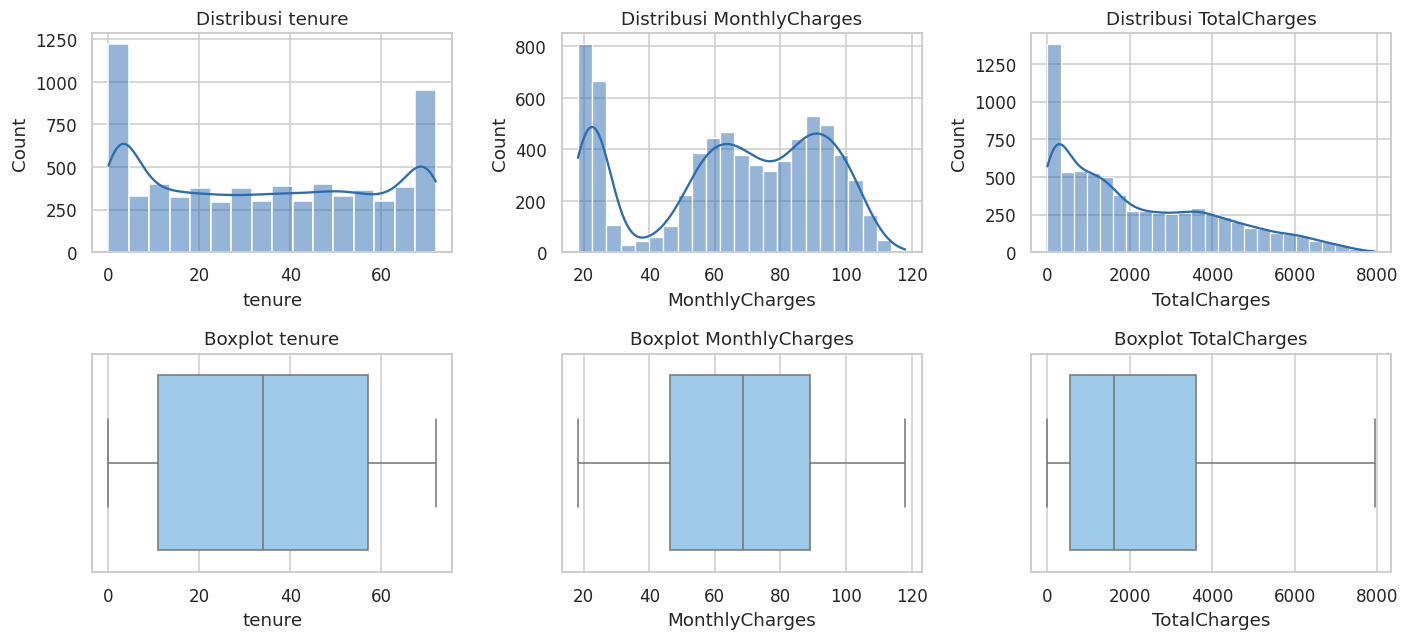

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for i, c in enumerate(NUM_COLS):
    sns.histplot(df[c], kde=True, ax=axes[0, i], color="#2b6cb0"); axes[0, i].set_title(f"Distribusi {c}")
    sns.boxplot(x=df[c], ax=axes[1, i], color="#90cdf4"); axes[1, i].set_title(f"Boxplot {c}")
plt.tight_layout(); plt.show()

**Interpretasi.** Ketiga fitur berada pada **skala yang sangat berbeda** (`tenure` puluhan, `MonthlyCharges` ratusan, `TotalCharges` hingga ribuan) dan `TotalCharges` cenderung condong ke kanan (*right-skewed*) karena merupakan akumulasi tagihan. Perbedaan skala ini penting untuk algoritma berbasis jarak/gradien (KNN, Logistic Regression), tetapi tidak berarti ada outlier yang perlu dibuang — nilai besar pada `TotalCharges` adalah pelanggan lama yang sah.

## 5. Categorical Analysis

In [11]:
cat_cols_all = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c]) and c not in (ID_COL, TARGET)] + ["SeniorCitizen"]
cat_summary = pd.DataFrame({
    "n_unique": df[cat_cols_all].nunique(),
    "kategori": {c: sorted(df[c].unique().tolist()) for c in cat_cols_all},
    "modus": {c: df[c].mode()[0] for c in cat_cols_all},
    "pct_modus": {c: round(df[c].value_counts(normalize=True).iloc[0] * 100, 1) for c in cat_cols_all},
})
cat_summary

,n_unique,kategori,modus,pct_modus
gender,2,"[Female, Male]",Male,50.9
Partner,2,"[No, Yes]",No,50.9
Dependents,2,"[No, Yes]",No,72.9
PhoneService,2,"[No, Yes]",Yes,92.6
MultipleLines,3,"[No, No phone service, Yes]",No,48.9
InternetService,3,"[DSL, Fiber optic, No]",Fiber optic,43.4
OnlineSecurity,3,"[No, No internet service, Yes]",No,49.9
OnlineBackup,3,"[No, No internet service, Yes]",No,43.8
DeviceProtection,3,"[No, No internet service, Yes]",No,43.8
TechSupport,3,"[No, No internet service, Yes]",No,50.4


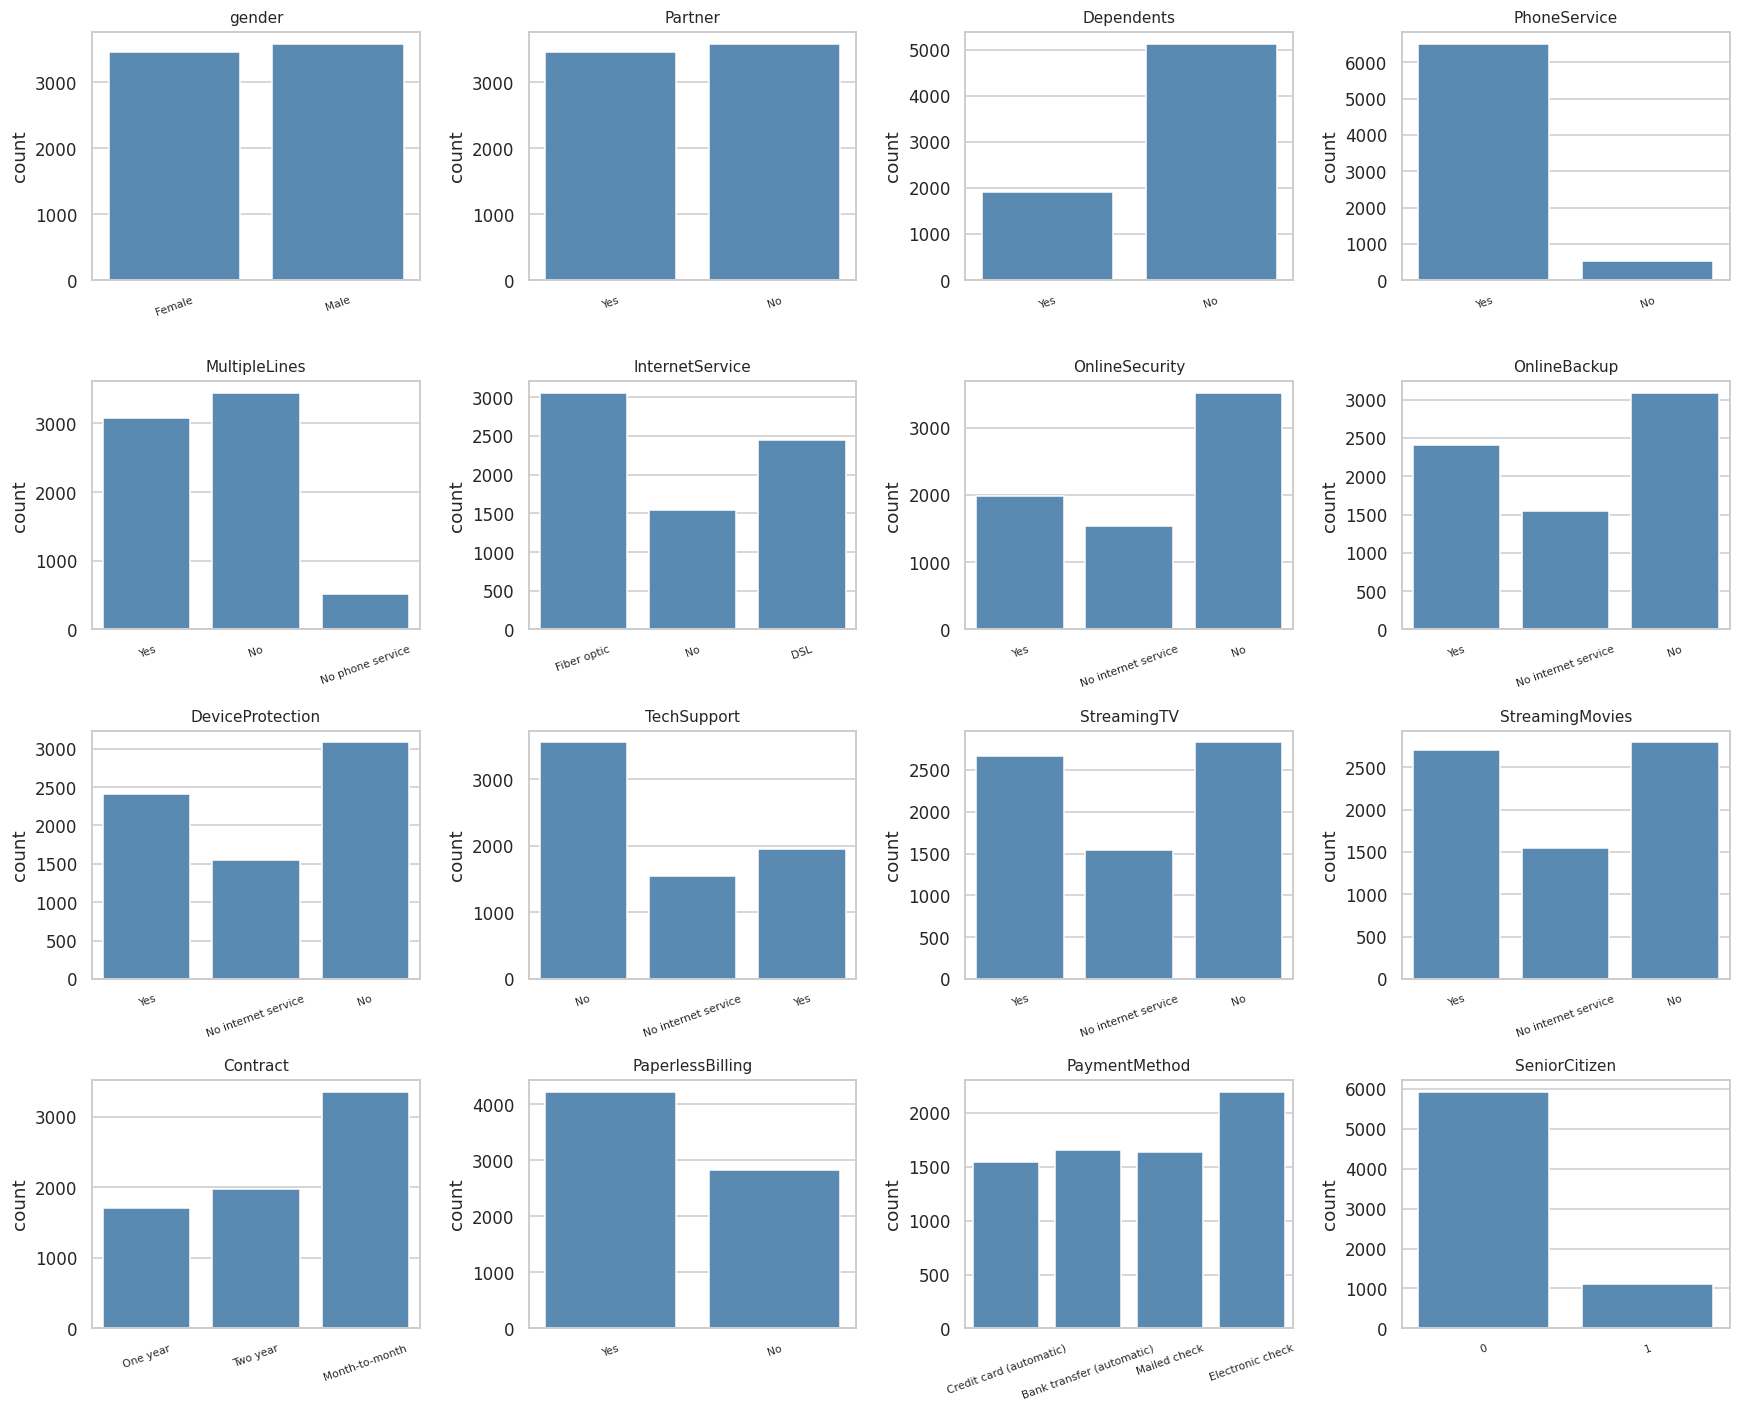

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
for ax, c in zip(axes.ravel(), cat_cols_all):
    sns.countplot(x=df[c].astype(str), ax=ax, color="#4c8bbf")
    ax.set_title(c, fontsize=10); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20, labelsize=7)
plt.tight_layout(); plt.show()

### Klasifikasi tipe kategorikal dan teknik encoding
| Kelompok | Atribut | Alasan | Encoding |
|---|---|---|---|
| **Ordinal** | `Contract` (Month-to-month < One year < Two year) | Kategori memiliki urutan komitmen yang bermakna | `OrdinalEncoder` dengan urutan eksplisit |
| **Biner** | `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `SeniorCitizen` | Hanya dua nilai | `OneHotEncoder(drop="if_binary")` → 1 kolom 0/1 |
| **Nominal (>2 kategori)** | `PaymentMethod`, `InternetService`, `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | Tidak ada urutan | `OneHotEncoder(handle_unknown="ignore")` |

Label encoding pada atribut nominal sengaja dihindari karena memberi urutan semu (mis. `Credit card` > `Bank transfer`) yang menyesatkan model berbasis jarak/linier. Pada kolom seperti `OnlineSecurity`, level `No internet service` dipertahankan sebagai kategori sendiri karena merepresentasikan kondisi yang nyata (tidak punya layanan internet).

In [13]:
ORDINAL_COLS = {"Contract": ["Month-to-month", "One year", "Two year"]}
BIN_COLS = [c for c in cat_cols_all if df[c].nunique() == 2 and c not in ORDINAL_COLS]
NOM_COLS = [c for c in cat_cols_all if c not in BIN_COLS and c not in ORDINAL_COLS]
R.update(n_bin=len(BIN_COLS), n_nom=len(NOM_COLS), n_ord=len(ORDINAL_COLS), n_cat=len(cat_cols_all))
print("Ordinal :", list(ORDINAL_COLS))
print("Biner   :", BIN_COLS)
print("Nominal :", NOM_COLS)
print()
print("Churn rate per Contract (mendukung perlakuan ordinal):")
(df.groupby("Contract")[TARGET].apply(lambda s: round((s == "Yes").mean() * 100, 1))
   .reindex(ORDINAL_COLS["Contract"]).rename("churn_rate_%").to_frame())

Ordinal : ['Contract']
Biner   : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen']
Nominal : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']

Churn rate per Contract (mendukung perlakuan ordinal):


,churn_rate_%
Contract,
Month-to-month,43.4
One year,17.4
Two year,5.7


## 6. Imbalance Analysis

In [14]:
y_all = (df[TARGET] == "Yes").astype(int)
class_counts = y_all.value_counts().sort_index()
n_neg, n_pos = int(class_counts[0]), int(class_counts[1])
ratio = n_neg / n_pos
R.update(n_neg=n_neg, n_pos=n_pos, ratio=float(ratio), pos_pct=float(n_pos / len(y_all) * 100))
print(f"Tidak churn (0): {n_neg:,} ({n_neg/len(y_all):.1%})")
print(f"Churn       (1): {n_pos:,} ({n_pos/len(y_all):.1%})")
print(f"Rasio mayoritas : minoritas = {ratio:.2f} : 1")
print(f"Akurasi model 'tebak selalu tidak churn' = {n_neg/len(y_all):.1%}  <- baseline yang menyesatkan")

Tidak churn (0): 5,177 (73.5%)
Churn       (1): 1,866 (26.5%)
Rasio mayoritas : minoritas = 2.77 : 1
Akurasi model 'tebak selalu tidak churn' = 73.5%  <- baseline yang menyesatkan


**Interpretasi.** Rasio sekitar 2,8 : 1 tergolong **imbalance sedang (moderate)**, bukan ekstrem. Dampaknya tetap nyata: model dapat mencapai akurasi tinggi hanya dengan menebak mayoritas, sementara kelas yang justru penting bagi bisnis (pelanggan churn) terlewat. Karena itu evaluasi tidak boleh bertumpu pada *accuracy* saja, tetapi pada **recall, precision, F1, dan ROC-AUC kelas churn**.

## 7. Train–Test Split (sebelum fitting apa pun)
Split dilakukan **paling awal** dan **stratified** supaya proporsi churn sama di train dan test. Semua statistik (median, mean, std, kategori, tetangga SMOTE) hanya boleh dipelajari dari *train*.

In [15]:
X = df.drop(columns=[ID_COL, TARGET])      # customerID dibuang: identifier unik, tidak punya makna prediktif
y = y_all
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
R.update(n_train=len(X_train), n_test=len(X_test))
pd.DataFrame({"n_baris": [len(X_train), len(X_test)],
              "churn_rate_%": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)]},
             index=["Train", "Test"])

,n_baris,churn_rate_%
Train,5634,26.50
Test,1409,26.47


## 8. Preprocessing Pipeline (`ColumnTransformer`)
Struktur sesuai skema tugas: fitur numerik → *imputation + scaling*; fitur kategorikal → *imputation + encoding*. Fungsi dibuat dengan parameter `scale` agar eksperimen A (tanpa scaling) dan B (StandardScaler) memakai pipeline yang sama persis kecuali pada langkah scaling.

In [16]:
def build_preprocessor(scale=True):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(num_steps), NUM_COLS),
            ("bin", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                              ("enc", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))]), BIN_COLS),
            ("nom", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                              ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), NOM_COLS),
            ("ord", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                              ("enc", OrdinalEncoder(categories=[ORDINAL_COLS[c] for c in ORDINAL_COLS]))]), list(ORDINAL_COLS)),
        ],
        remainder="drop", sparse_threshold=0, verbose_feature_names_out=False)

prep_scaled, prep_noscale = build_preprocessor(True), build_preprocessor(False)
Xtr_s  = prep_scaled.fit_transform(X_train);  Xte_s  = prep_scaled.transform(X_test)     # fit HANYA di train
Xtr_ns = prep_noscale.fit_transform(X_train); Xte_ns = prep_noscale.transform(X_test)
feature_names = prep_scaled.get_feature_names_out()
R["n_features_out"] = len(feature_names)
print(f"Fitur mentah  : {X_train.shape[1]} kolom  ->  setelah pipeline: {Xtr_s.shape[1]} kolom")
print(f"Train: {Xtr_s.shape} | Test: {Xte_s.shape}")
print(f"NaN pada hasil transformasi -> train: {int(np.isnan(Xtr_s).sum())}, test: {int(np.isnan(Xte_s).sum())}")
pd.DataFrame(Xtr_s, columns=feature_names).head()

Fitur mentah  : 19 kolom  ->  setelah pipeline: 38 kolom
Train: (5634, 38) | Test: (1409, 38)
NaN pada hasil transformasi -> train: 0, test: 0


,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,SeniorCitizen_1,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract
0,0.628212,-0.371062,0.263026,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.381059,0.688426,0.829215,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0
2,-0.483974,-0.343709,-0.530443,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
3,-0.525166,0.768298,-0.145772,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,-0.360398,0.921477,0.018368,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


### Bukti scaling tidak bocor
Setelah `StandardScaler` di-*fit* pada train, rata-rata/standar deviasi **train** tepat 0/1, sedangkan **test** mendekati tetapi tidak persis 0/1. Itu justru tanda yang benar: test diperlakukan sebagai data baru yang belum pernah dilihat.

In [17]:
idx = [list(feature_names).index(c) for c in NUM_COLS]
chk = pd.DataFrame({
    "mean_train": Xtr_s[:, idx].mean(0), "std_train": Xtr_s[:, idx].std(0),
    "mean_test":  Xte_s[:, idx].mean(0), "std_test":  Xte_s[:, idx].std(0)}, index=NUM_COLS)
chk.round(3)

,mean_train,std_train,mean_test,std_test
tenure,-0.0,1.0,-0.032,0.994
MonthlyCharges,0.0,1.0,-0.068,1.033
TotalCharges,-0.0,1.0,-0.044,0.999


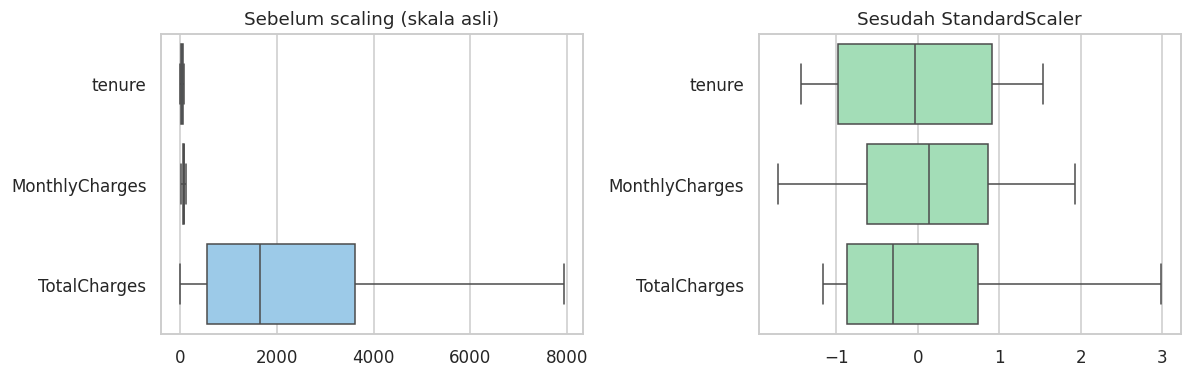

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sns.boxplot(data=X_train[NUM_COLS], orient="h", ax=axes[0], color="#90cdf4"); axes[0].set_title("Sebelum scaling (skala asli)")
sns.boxplot(data=pd.DataFrame(Xtr_s[:, idx], columns=NUM_COLS), orient="h", ax=axes[1], color="#9ae6b4"); axes[1].set_title("Sesudah StandardScaler")
plt.tight_layout(); plt.savefig(f"{ARTIFACT_DIR}/fig_scaling.png", dpi=170, bbox_inches="tight"); plt.show()

## 9. Imbalance Handling
Dua strategi dibandingkan, **keduanya hanya menyentuh data training**:
1. **`class_weight="balanced"`** — data tidak diubah; kesalahan pada kelas minoritas diberi bobot lebih besar saat training.
2. **SMOTE** — membuat sampel sintetis kelas minoritas dengan interpolasi antar-tetangga terdekat. SMOTE bekerja pada ruang numerik, maka diterapkan **setelah** encoding & scaling, **pada train saja**.

Jika pustaka `imbalanced-learn` tersedia, dipakai `imblearn.SMOTE`; jika tidak, dipakai implementasi SMOTE sederhana (algoritma yang sama: interpolasi ke *k* tetangga terdekat) di bawah.

In [19]:
try:
    from imblearn.over_sampling import SMOTE as _IMB_SMOTE
    HAS_IMBLEARN = True
except Exception:
    HAS_IMBLEARN = False

def simple_smote(X, y, k_neighbors=5, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, float); y = np.asarray(y)
    classes, counts = np.unique(y, return_counts=True)
    minor = classes[counts.argmin()]
    n_new = counts.max() - counts.min()
    X_min = X[y == minor]
    nn = NearestNeighbors(n_neighbors=k_neighbors + 1).fit(X_min)
    neigh = nn.kneighbors(X_min, return_distance=False)[:, 1:]     # buang diri sendiri
    base = rng.integers(0, len(X_min), n_new)
    pick = neigh[base, rng.integers(0, k_neighbors, n_new)]
    lam = rng.random((n_new, 1))
    X_syn = X_min[base] + lam * (X_min[pick] - X_min[base])
    return np.vstack([X, X_syn]), np.concatenate([y, np.full(n_new, minor)])

def apply_smote(X, y):
    if HAS_IMBLEARN:
        return _IMB_SMOTE(random_state=RANDOM_STATE).fit_resample(X, y)
    return simple_smote(X, y)

print("Implementasi SMOTE:", "imblearn" if HAS_IMBLEARN else "simple_smote (manual)")
Xtr_sm, ytr_sm = apply_smote(Xtr_s, y_train)      # <-- hanya train
dist = pd.DataFrame({
    "Train asli":    [int((y_train == 0).sum()), int((y_train == 1).sum())],
    "Train + SMOTE": [int((ytr_sm == 0).sum()),  int((ytr_sm == 1).sum())],
    "Test (tidak diubah)": [int((y_test == 0).sum()), int((y_test == 1).sum())]}, index=["Tidak churn (0)", "Churn (1)"])
R["dist"] = dist.to_dict()
R["n_train_smote"] = int(len(ytr_sm))
dist

Implementasi SMOTE: simple_smote (manual)


,Train asli,Train + SMOTE,Test (tidak diubah)
Tidak churn (0),4141,4141,1036
Churn (1),1493,4141,373


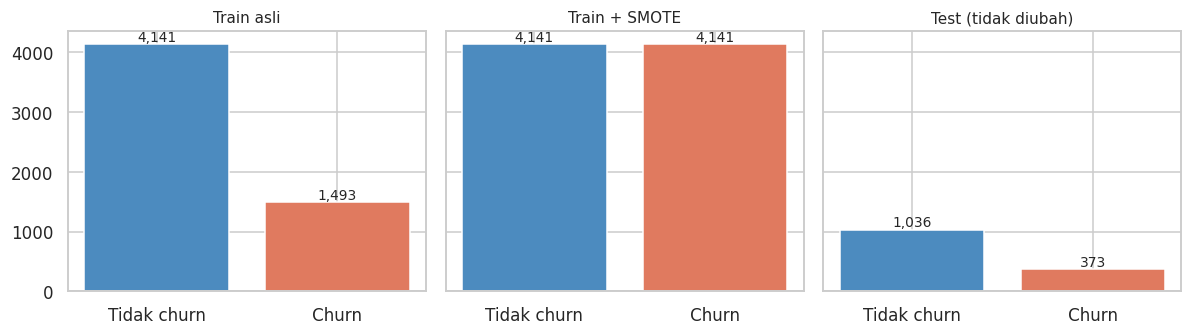

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, col in zip(axes, dist.columns):
    ax.bar(["Tidak churn", "Churn"], dist[col].values, color=["#4c8bbf", "#e07a5f"])
    for i, v in enumerate(dist[col].values): ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
    ax.set_title(col, fontsize=10)
plt.tight_layout(); plt.savefig(f"{ARTIFACT_DIR}/fig_class.png", dpi=170, bbox_inches="tight"); plt.show()

In [21]:
# Catatan teknis: SMOTE standar menginterpolasi SEMUA kolom, termasuk dummy 0/1
j = [k for k, n in enumerate(feature_names) if n == BIN_COLS[0] or n.startswith(BIN_COLS[0] + '_')][0]
print(f"Kolom dummy '{feature_names[j]}' sebelum SMOTE: {len(np.unique(Xtr_s[:, j]))} nilai unik; sesudah SMOTE: {len(np.unique(Xtr_sm[:, j]))} nilai unik")

Kolom dummy 'gender_Male' sebelum SMOTE: 2 nilai unik; sesudah SMOTE: 719 nilai unik


**Interpretasi & keterbatasan.** Setelah SMOTE, train menjadi seimbang 50:50 sedangkan **test tetap memiliki distribusi asli** — ini penting agar evaluasi mencerminkan kondisi nyata. Perhatikan bahwa SMOTE standar menghasilkan nilai pecahan pada kolom dummy (yang seharusnya 0/1). Untuk data campuran numerik+kategorikal, varian **SMOTENC** (atau SMOTE sebelum encoding) lebih tepat secara teoritis; di sini SMOTE standar dipakai karena tujuan tugas adalah menunjukkan posisi yang benar dalam pipeline dan dampaknya terhadap distribusi kelas.

## 10. Eksperimen Kecil: dampak preprocessing
Model sederhana (Logistic Regression, KNN, Decision Tree) dipakai **hanya sebagai alat observasi**, bukan untuk mengejar akurasi terbaik. Semua metrik dihitung pada **test set asli** (kelas churn = kelas positif).

| Eksperimen | Perlakuan |
|---|---|
| A | Tanpa scaling (baseline) |
| B | Dengan `StandardScaler` |
| C | Scaling aktif, tanpa imbalance handling (baseline distribusi kelas) |
| D1 / D2 | Scaling + `class_weight="balanced"` / Scaling + SMOTE |

*B dan C memakai data & model yang sama (keduanya adalah baseline scaling-aktif tanpa imbalance handling); dipisah hanya untuk memperjelas dua perbandingan: A vs B (scaling) dan C vs D (imbalance).* KNN tidak memiliki parameter `class_weight`, sehingga D1 tidak berlaku untuk KNN.

In [22]:
def evaluate(model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred, proba = model.predict(Xte), model.predict_proba(Xte)[:, 1]
    return dict(accuracy=accuracy_score(yte, pred), precision=precision_score(yte, pred, zero_division=0),
                recall=recall_score(yte, pred), f1=f1_score(yte, pred), roc_auc=roc_auc_score(yte, proba)), pred

LR  = lambda **kw: LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, **kw)
KNN = lambda: KNeighborsClassifier(n_neighbors=15)
TREE = lambda: DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)

rows, preds = [], {}
def add(model, exp, desc, Xtr, ytr, Xte, mdl):
    res, pred = evaluate(mdl, Xtr, ytr, Xte, y_test)
    preds[(model, exp)] = pred
    rows.append({"Model": model, "Eksp": exp, "Perlakuan": desc, **res})

add("LogReg", "A",  "Tanpa scaling",                    Xtr_ns, y_train, Xte_ns, LR())
add("LogReg", "B",  "StandardScaler",                   Xtr_s,  y_train, Xte_s,  LR())
add("LogReg", "C",  "Scaling, tanpa imbalance handling", Xtr_s, y_train, Xte_s,  LR())
add("LogReg", "D1", "Scaling + class_weight",           Xtr_s,  y_train, Xte_s,  LR(class_weight="balanced"))
add("LogReg", "D2", "Scaling + SMOTE (train)",          Xtr_sm, ytr_sm,  Xte_s,  LR())

add("KNN",    "A",  "Tanpa scaling",                    Xtr_ns, y_train, Xte_ns, KNN())
add("KNN",    "B",  "StandardScaler",                   Xtr_s,  y_train, Xte_s,  KNN())
add("KNN",    "C",  "Scaling, tanpa imbalance handling", Xtr_s, y_train, Xte_s,  KNN())
add("KNN",    "D2", "Scaling + SMOTE (train)",          Xtr_sm, ytr_sm,  Xte_s,  KNN())

add("Tree",   "A",  "Tanpa scaling",                    Xtr_ns, y_train, Xte_ns, TREE())
add("Tree",   "B",  "StandardScaler",                   Xtr_s,  y_train, Xte_s,  TREE())

exp_df = pd.DataFrame(rows)
R["exp"] = exp_df.round(4).to_dict(orient="records")
exp_df.round(3)

,Model,Eksp,Perlakuan,accuracy,precision,recall,f1,roc_auc
0,LogReg,A,Tanpa scaling,0.814,0.708,0.507,0.591,0.860
1,LogReg,B,StandardScaler,0.815,0.711,0.507,0.592,0.860
2,LogReg,C,"Scaling, tanpa imbalance handling",0.815,0.711,0.507,0.592,0.860
3,LogReg,D1,Scaling + class_weight,0.751,0.519,0.788,0.626,0.860
4,LogReg,D2,Scaling + SMOTE (train),0.760,0.532,0.775,0.631,0.860
5,KNN,A,Tanpa scaling,0.762,0.581,0.367,0.450,0.772
6,KNN,B,StandardScaler,0.802,0.665,0.507,0.575,0.830
7,KNN,C,"Scaling, tanpa imbalance handling",0.802,0.665,0.507,0.575,0.830
8,KNN,D2,Scaling + SMOTE (train),0.705,0.467,0.804,0.591,0.820
9,Tree,A,Tanpa scaling,0.803,0.678,0.491,0.569,0.835


In [23]:
def g(model, e, m): return exp_df[(exp_df.Model == model) & (exp_df.Eksp == e)][m].iloc[0]

print("== Efek SCALING (A -> B) ==")
for m in ["LogReg", "KNN"]:
    print(f"{m:7s} ROC-AUC {g(m,'A','roc_auc'):.3f} -> {g(m,'B','roc_auc'):.3f} | F1 {g(m,'A','f1'):.3f} -> {g(m,'B','f1'):.3f}")
agree = float((preds[("Tree", "A")] == preds[("Tree", "B")]).mean())
R["tree_agree"] = agree
print(f"Tree    ROC-AUC {g('Tree','A','roc_auc'):.3f} -> {g('Tree','B','roc_auc'):.3f} | prediksi identik pada {agree:.1%} sampel test")

print("\n== Efek IMBALANCE HANDLING (C -> D), kelas churn ==")
for m, ex in [("LogReg", "D1"), ("LogReg", "D2"), ("KNN", "D2")]:
    print(f"{m:7s} {ex}: recall {g(m,'C','recall'):.3f} -> {g(m,ex,'recall'):.3f} | precision {g(m,'C','precision'):.3f} -> {g(m,ex,'precision'):.3f} | "
          f"F1 {g(m,'C','f1'):.3f} -> {g(m,ex,'f1'):.3f} | accuracy {g(m,'C','accuracy'):.3f} -> {g(m,ex,'accuracy'):.3f}")

== Efek SCALING (A -> B) ==
LogReg  ROC-AUC 0.860 -> 0.860 | F1 0.591 -> 0.592
KNN     ROC-AUC 0.772 -> 0.830 | F1 0.450 -> 0.575
Tree    ROC-AUC 0.835 -> 0.835 | prediksi identik pada 100.0% sampel test

== Efek IMBALANCE HANDLING (C -> D), kelas churn ==
LogReg  D1: recall 0.507 -> 0.788 | precision 0.711 -> 0.519 | F1 0.592 -> 0.626 | accuracy 0.815 -> 0.751
LogReg  D2: recall 0.507 -> 0.775 | precision 0.711 -> 0.532 | F1 0.592 -> 0.631 | accuracy 0.815 -> 0.760
KNN     D2: recall 0.507 -> 0.804 | precision 0.665 -> 0.467 | F1 0.575 -> 0.591 | accuracy 0.802 -> 0.705


### Interpretasi hasil eksperimen
- **Scaling (A vs B).** Pengaruh terbesar terlihat pada **KNN** karena jaraknya didominasi fitur berskala besar (`TotalCharges`, `MonthlyCharges`) jika tidak di-scale; fitur kecil seperti dummy 0/1 hampir tidak berkontribusi. **Logistic Regression** lebih toleran terhadap skala untuk akurasi akhir, tetapi scaling tetap penting untuk kecepatan/stabilitas konvergensi gradien dan agar koefisien dapat dibandingkan. Pada **Decision Tree**, hasil A dan B praktis identik karena split pohon hanya bergantung pada *urutan* nilai fitur, dan scaling (transformasi monoton) tidak mengubah urutan — itulah alasan scaling tidak kritis untuk algoritma berbasis tree.
- **Imbalance (C vs D).** Tanpa penanganan, model cenderung condong ke kelas mayoritas: *recall* churn rendah walaupun *accuracy* tampak baik. `class_weight` maupun SMOTE menaikkan **recall churn** dengan imbalan **precision dan accuracy yang turun** (lebih banyak pelanggan "tidak churn" yang salah ditandai churn). Ini trade-off, bukan kegagalan: bagi bisnis, melewatkan pelanggan yang akan churn biasanya lebih mahal daripada menghubungi pelanggan yang sebenarnya aman, sehingga recall layak diprioritaskan. `class_weight` lebih sederhana dan tidak mengubah data, sedangkan SMOTE mengubah data training dan harus dijaga agar tidak bocor ke test.
- **Peringatan metrik.** Karena distribusi test dibiarkan asli, accuracy turun setelah resampling adalah hal yang wajar dan tidak boleh dibaca sebagai "model lebih buruk" tanpa melihat recall/F1/ROC-AUC.

## 11. Data Leakage: identifikasi dan demonstrasi
**Kemungkinan leakage dalam preprocessing (minimal dua, dibahas empat):**
1. **Fit transformer pada seluruh data sebelum split** — mean/std `StandardScaler`, median imputer, atau kategori encoder "mengintip" test set.
2. **Resampling (SMOTE) sebelum split** — sampel sintetis dibuat dari tetangga yang sebagian berasal dari data yang kemudian masuk test, sehingga test berisi titik yang hampir salinan train.
3. **Kolom identifier / turunan target** — `customerID` (unik per baris) atau kolom seperti *Churn Reason*, *Churn Score* pada versi lain dataset Telco yang hanya diketahui setelah pelanggan churn.
4. **Cross-validation tanpa membungkus preprocessing di dalam `Pipeline`** — statistik dihitung pada seluruh fold termasuk fold validasi.

Dua yang pertama didemonstrasikan secara empiris berikut ini.

In [24]:
# Demo 1: scaler yang di-fit pada SEMUA data vs hanya train
leak_sc = StandardScaler().fit(X[NUM_COLS]); ok_sc = StandardScaler().fit(X_train[NUM_COLS])
demo1 = pd.DataFrame({"mean (fit semua data) [bocor]": leak_sc.mean_, "mean (fit train saja) [benar]": ok_sc.mean_,
                      "selisih": leak_sc.mean_ - ok_sc.mean_}, index=NUM_COLS)
demo1.round(3)

,mean (fit semua data) [bocor],mean (fit train saja) [benar],selisih
tenure,34.594,34.749,-0.155
MonthlyCharges,64.933,65.304,-0.371
TotalCharges,2202.626,2219.355,-16.730


In [25]:
# Demo 2: SMOTE (dan preprocessing) SEBELUM split -> metrik terlihat lebih bagus daripada kenyataan
prep_leak = build_preprocessor(True)
X_all_leak = prep_leak.fit_transform(X)                       # kebocoran 1: fit pada semua data
X_sm_all, y_sm_all = apply_smote(X_all_leak, y)               # kebocoran 2: SMOTE sebelum split
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(X_sm_all, y_sm_all, test_size=0.20, stratify=y_sm_all, random_state=RANDOM_STATE)
res_leak, _ = evaluate(KNN(), Xl_tr, yl_tr, Xl_te, yl_te)
res_ok = {k: g("KNN", "D2", k) for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]}
R["leak_demo"] = {"leaky": {k: float(v) for k, v in res_leak.items()}, "correct": {k: float(v) for k, v in res_ok.items()}}
pd.DataFrame({"KNN + SMOTE sebelum split [BOCOR]": res_leak, "KNN + SMOTE hanya di train [BENAR]": res_ok}).T.round(3)

,accuracy,precision,recall,f1,roc_auc
KNN + SMOTE sebelum split [BOCOR],0.788,0.735,0.899,0.809,0.877
KNN + SMOTE hanya di train [BENAR],0.705,0.467,0.804,0.591,0.820


**Interpretasi.** Skor pada skenario bocor terlihat lebih tinggi, tetapi angka itu **palsu**: test set-nya sudah seimbang buatan dan berisi sampel sintetis yang diturunkan dari tetangga sesama titik data, sehingga model tinggal "mengenali" tetangganya. Skor skenario benar (SMOTE hanya di train, test asli) adalah gambaran jujur performa pada pelanggan baru. Karena itu urutan yang benar selalu **split → fit preprocessing di train → resample di train → evaluasi di test asli**.

### Mengapa SMOTE hanya pada training data?
- Test set harus mensimulasikan **data masa depan yang belum pernah dilihat** dengan distribusi **dunia nyata**. Jika SMOTE dilakukan sebelum split, distribusi test menjadi artifisial (50:50) dan tidak mewakili populasi sebenarnya.
- Sampel sintetis dibuat dari interpolasi sampel nyata. Sebelum split, sampel sintetis dari tetangga yang sama dapat jatuh di train dan test sekaligus (*near-duplicate*), sehingga informasi test merembes ke training.
- Metrik menjadi **terlalu optimis** (terbukti pada Demo 2) dan tidak dapat dipercaya untuk keputusan bisnis.

## 12. Validation Note: pembuktian otomatis tidak ada leakage & dataset siap model

In [26]:
scaler_fit = prep_scaled.named_transformers_["num"].named_steps["scaler"]
checks = {
    "Tidak ada NaN pada train/test hasil transformasi": (not np.isnan(Xtr_s).any()) and (not np.isnan(Xte_s).any()),
    "Jumlah fitur train == test": Xtr_s.shape[1] == Xte_s.shape[1] == len(feature_names),
    "Scaler dipelajari dari TRAIN saja (mean_scaler == mean train)": np.allclose(scaler_fit.mean_, X_train[NUM_COLS].mean().values),
    "Scaler berbeda dari statistik seluruh data (tidak mengintip test)": not np.allclose(scaler_fit.mean_, X[NUM_COLS].mean().values),
    "SMOTE: train seimbang sempurna": (ytr_sm == 0).sum() == (ytr_sm == 1).sum(),
    "Test tidak diubah oleh resampling (n & rasio churn sama dengan split awal)": (len(Xte_s) == len(y_test)) and abs(y_test.mean() - y.mean()) < 0.005,
    "Split stratified (selisih churn rate train vs test < 0.5 pp)": abs(y_train.mean() - y_test.mean()) < 0.005,
    "customerID tidak ada di fitur": ID_COL not in X.columns and TARGET not in X.columns,
}
for k, v in checks.items(): print(("[OK]  " if v else "[GAGAL] ") + k)
assert all(checks.values()), "Ada pemeriksaan yang gagal!"
R["checks_passed"] = int(sum(checks.values())); R["checks_total"] = len(checks)
print("\nVALIDASI LULUS:", R["checks_passed"], "/", R["checks_total"])

[OK]  Tidak ada NaN pada train/test hasil transformasi
[OK]  Jumlah fitur train == test
[OK]  Scaler dipelajari dari TRAIN saja (mean_scaler == mean train)
[OK]  Scaler berbeda dari statistik seluruh data (tidak mengintip test)
[OK]  SMOTE: train seimbang sempurna
[OK]  Test tidak diubah oleh resampling (n & rasio churn sama dengan split awal)
[OK]  Split stratified (selisih churn rate train vs test < 0.5 pp)
[OK]  customerID tidak ada di fitur

VALIDASI LULUS: 8 / 8


In [27]:
import joblib
joblib.dump(prep_scaled, f"{ARTIFACT_DIR}/preprocessing_pipeline.joblib")
final_cond = pd.DataFrame({
    "Train (sebelum SMOTE)": [Xtr_s.shape[0], Xtr_s.shape[1], int(np.isnan(Xtr_s).sum()), f"{y_train.mean():.1%}"],
    "Train (setelah SMOTE)": [Xtr_sm.shape[0], Xtr_sm.shape[1], int(np.isnan(Xtr_sm).sum()), f"{ytr_sm.mean():.1%}"],
    "Test (asli)":           [Xte_s.shape[0],  Xte_s.shape[1],  int(np.isnan(Xte_s).sum()),  f"{y_test.mean():.1%}"]},
    index=["n_baris", "n_fitur", "n_missing", "proporsi churn"])
final_cond

,Train (sebelum SMOTE),Train (setelah SMOTE),Test (asli)
n_baris,5634,8282,1409
n_fitur,38,38,38
n_missing,0,0,0
proporsi churn,26.5%,50.0%,26.5%


## 13. Jawaban Pertanyaan Analisis Wajib

In [28]:
print("1) MISSING VALUES")
print(f"   Sebelum penanganan: {R['missing_before'] or 'tidak ada'}  -> TotalCharges = {R['missing_pct_total']:.2f}% dari data")
strategy = pd.DataFrame([
    ["TotalCharges", f"{R['missing_before'].get('TotalCharges', 0)} (string kosong, tenure=0)", "Aturan bisnis: isi 0 bila tenure==0 (+ median imputer sbg safety net)",
     "Pelanggan baru belum ditagih -> 0 adalah nilai logis; median akan menyatakan tagihan ribuan yang palsu"],
    ["tenure, MonthlyCharges", "0", "SimpleImputer(strategy='median') di pipeline", "Median robust terhadap skewness/outlier; hanya jaring pengaman"],
    ["Seluruh atribut kategorikal", "0", "SimpleImputer(strategy='most_frequent') di pipeline", "Modus adalah satu-satunya ukuran sentral untuk data kategorikal"],
    ["customerID", "0", "Dibuang dari fitur", "Identifier unik, tanpa makna prediktif, risiko overfitting/leakage"]],
    columns=["Atribut", "Jumlah missing", "Strategi", "Alasan"])
display(strategy)

print("\n2) CATEGORICAL FEATURES")
print(f"   Ordinal ({R['n_ord']}): Contract -> OrdinalEncoder | Biner ({R['n_bin']}): OneHot drop='if_binary' | Nominal ({R['n_nom']}): OneHot handle_unknown='ignore'")

print("\n3) FEATURE SCALING")
print(f"   Di-scale: {NUM_COLS} (StandardScaler). Dummy 0/1 dan ordinal tidak di-scale (sudah berskala kecil).")
print("   Diperlukan untuk KNN/Logistic Regression (jarak & gradien sensitif skala); tidak kritis untuk tree (split bergantung urutan nilai).")

print("\n4) CLASS IMBALANCE")
print(f"   Rasio kelas = {R['n_neg']:,} : {R['n_pos']:,} = {R['ratio']:.2f} : 1 (churn {R['pos_pct']:.1f}%) -> imbalance sedang, perlu ditangani.")
print("   Strategi: class_weight='balanced' (model linear) dan SMOTE pada train (setelah encoding+scaling); evaluasi dengan recall/F1/ROC-AUC.")

print("\n5) SMOTE hanya di train -> lihat penjelasan bagian 11.  6) LEAKAGE -> lihat bagian 11 (4 kemungkinan, 2 didemonstrasikan).")

1) MISSING VALUES
   Sebelum penanganan: {'TotalCharges': 11}  -> TotalCharges = 0.16% dari data


,Atribut,Jumlah missing,Strategi,Alasan
0,TotalCharges,"11 (string kosong, tenure=0)",Aturan bisnis: isi 0 bila tenure==0 (+ median ...,Pelanggan baru belum ditagih -> 0 adalah nilai...
1,"tenure, MonthlyCharges",0,SimpleImputer(strategy='median') di pipeline,Median robust terhadap skewness/outlier; hanya...
2,Seluruh atribut kategorikal,0,SimpleImputer(strategy='most_frequent') di pip...,Modus adalah satu-satunya ukuran sentral untuk...
3,customerID,0,Dibuang dari fitur,"Identifier unik, tanpa makna prediktif, risiko..."



2) CATEGORICAL FEATURES
   Ordinal (1): Contract -> OrdinalEncoder | Biner (6): OneHot drop='if_binary' | Nominal (9): OneHot handle_unknown='ignore'

3) FEATURE SCALING
   Di-scale: ['tenure', 'MonthlyCharges', 'TotalCharges'] (StandardScaler). Dummy 0/1 dan ordinal tidak di-scale (sudah berskala kecil).
   Diperlukan untuk KNN/Logistic Regression (jarak & gradien sensitif skala); tidak kritis untuk tree (split bergantung urutan nilai).

4) CLASS IMBALANCE
   Rasio kelas = 5,177 : 1,866 = 2.77 : 1 (churn 26.5%) -> imbalance sedang, perlu ditangani.
   Strategi: class_weight='balanced' (model linear) dan SMOTE pada train (setelah encoding+scaling); evaluasi dengan recall/F1/ROC-AUC.

5) SMOTE hanya di train -> lihat penjelasan bagian 11.  6) LEAKAGE -> lihat bagian 11 (4 kemungkinan, 2 didemonstrasikan).


## 14. Executive Data Quality Report (PDF, ≤ 3 halaman)
Sel berikut menyusun laporan **otomatis dari angka-angka di atas** sehingga selalu konsisten dengan hasil notebook. Hasilnya disimpan sebagai `P02_<NIM>_<Nama>_Report.pdf`.

In [29]:
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib.enums import TA_JUSTIFY, TA_CENTER
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, KeepTogether
from pypdf import PdfReader
import datetime

def n(x, d=0):                       # format angka Indonesia: 7.043 dan 26,5
    return f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")
pct = lambda x, d=1: n(x, d) + "%"
pc = lambda x: n(x * 100, 2) + "%"
arah = lambda d: "naik" if d > 0 else "turun"
BULAN = ["Januari", "Februari", "Maret", "April", "Mei", "Juni", "Juli", "Agustus", "September", "Oktober", "November", "Desember"]
today = datetime.date.today()
TANGGAL = f"{CITY}, {today.day:02d} {BULAN[today.month-1]} {today.year}"
CHK = "\u2022"                                       # penanda butir (font Times standar tidak punya simbol centang)
AR = "-&gt;"                                           # panah (font Times standar tidak punya simbol panah)

F, FB, FI = "Times-Roman", "Times-Bold", "Times-Italic"
em = exp_df.set_index(["Model", "Eksp"])
v = lambda m, e, k: em.loc[(m, e), k]
nr = R["num_range"]; lk, ok = R["leak_demo"]["leaky"], R["leak_demo"]["correct"]
nm = R["missing_before"].get("TotalCharges", 0)
dd = R["dist"]; tr_neg, tr_pos = dd["Train asli"]["Tidak churn (0)"], dd["Train asli"]["Churn (1)"]
sm_neg, sm_pos = dd["Train + SMOTE"]["Tidak churn (0)"], dd["Train + SMOTE"]["Churn (1)"]
dK_auc = v("KNN", "B", "roc_auc") - v("KNN", "A", "roc_auc")
dK_acc = v("KNN", "B", "accuracy") - v("KNN", "A", "accuracy")
dRec = v("LogReg", "D1", "recall") - v("LogReg", "C", "recall")
dPre = v("LogReg", "D1", "precision") - v("LogReg", "C", "precision")
dAcc = v("LogReg", "D1", "accuracy") - v("LogReg", "C", "accuracy")

def build(fs):
    ld = fs * 1.2
    sBody = ParagraphStyle("b", fontName=F, fontSize=fs, leading=ld, alignment=TA_JUSTIFY, leftIndent=14, spaceAfter=1)
    sTitle = ParagraphStyle("t", fontName=FB, fontSize=fs + 1.5, leading=ld + 2, alignment=TA_CENTER, spaceAfter=3)
    sSec = ParagraphStyle("sec", fontName=FB, fontSize=fs + 1, leading=ld + 1, spaceBefore=6, spaceAfter=2, keepWithNext=1)
    sSub = ParagraphStyle("sub", fontName=FB, fontSize=fs, leading=ld, leftIndent=14, spaceBefore=3, keepWithNext=1)
    sLab = ParagraphStyle("lab", fontName=F, fontSize=fs, leading=ld, leftIndent=28, spaceBefore=2, alignment=TA_JUSTIFY)
    sBul = ParagraphStyle("bul", fontName=F, fontSize=fs, leading=ld, leftIndent=40, bulletIndent=30, alignment=TA_JUSTIFY)
    sCell = ParagraphStyle("c", fontName=F, fontSize=fs - 0.8, leading=ld - 0.8)
    sCellB = ParagraphStyle("cb", fontName=FB, fontSize=fs - 0.8, leading=ld - 0.8, alignment=TA_CENTER)
    W = A4[0] - 3.6 * cm
    Sec = lambda t: Paragraph(t, sSec)
    Sub = lambda t: Paragraph(t, sSub)
    Lab = lambda t: Paragraph(t, sLab)
    Bl = lambda t: Paragraph(t, sBul, bulletText="\u2022")
    P = lambda t: Paragraph(t, sBody)
    def T(rows, widths, indent=0):
        data = [[Paragraph(str(c), sCellB if i == 0 else sCell) for c in r] for i, r in enumerate(rows)]
        t = Table(data, colWidths=widths, hAlign="CENTER")
        st = [("GRID", (0, 0), (-1, -1), 0.4, colors.HexColor("#6f8fbf")), ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#dce6f4")),
              ("VALIGN", (0, 0), (-1, -1), "MIDDLE"), ("TOPPADDING", (0, 0), (-1, -1), 1.5), ("BOTTOMPADDING", (0, 0), (-1, -1), 1.5)]
        st += [("BACKGROUND", (0, i), (-1, i), colors.HexColor("#f2f6fb")) for i in range(2, len(rows), 2)]
        t.setStyle(TableStyle(st)); return KeepTogether([t])

    S = []
    S += [Paragraph("TUGAS MANDIRI 2", sTitle), Paragraph("Data Quality Audit &amp; Preprocessing Pipeline", sTitle),
          Paragraph("\u201cFrom Dirty Data to Model-Ready Data: Building a Preprocessing Pipeline\u201d", sTitle),
          Paragraph(f"{NAMA} ({NIM})", sTitle)]
    if GITHUB_URL:
        S.append(Table([[Paragraph(f"<b>{GITHUB_URL}</b>", ParagraphStyle("g", fontName="Helvetica-Bold", fontSize=fs - 1, alignment=TA_CENTER))]], colWidths=[W],
                       style=[("BACKGROUND", (0, 0), (-1, -1), colors.HexColor("#b4c7e7"))]))
    if USING_STANDIN:
        S.append(Paragraph("<i>Catatan: angka pada laporan ini berasal dari dataset stand-in sintetis bergaya Telco; jalankan ulang notebook dengan file Telco asli untuk angka final.</i>",
                           ParagraphStyle("nt", fontName=FI, fontSize=fs - 1.5, leading=ld - 1.5, alignment=TA_CENTER, spaceBefore=2)))

    # ---------------- A ----------------
    S += [Sec("A.&nbsp; DATA QUALITY PROBLEMS IDENTIFIED"),
      P(f"Selama fase Data Understanding &amp; Audit pada dataset Telco Customer Churn ({n(R['n_rows'])} baris, {R['n_cols']} kolom; unit analisis = satu pelanggan; target = Churn), "
        "kami mengidentifikasi beberapa masalah kualitas data. Berikut masalah-masalah utama yang ditemukan dan strategi penanganannya:"),
      Sub("1) Missing Values"),
      Lab("Temuan:"),
      Bl(f"TotalCharges: {nm} records ({pct(R['missing_pct_total'],2)}) - kolom numerik yang tersimpan sebagai teks berisi spasi, sehingga isna() awalnya melaporkan 0 missing"),
      Bl("Semua baris tersebut memiliki tenure = 0 (pelanggan baru yang belum pernah ditagih), jadi kekosongannya bukan acak. Kolom lain: 0 missing"),
      Lab("Dampak Bisnis: model tidak dapat dilatih pada kolom bertipe teks; mengisi dengan mean/median memalsukan tagihan pelanggan baru; deletion mengurangi sample size."),
      Lab("Solusi yang Diterapkan:"),
      Bl("TotalCharges diisi 0 jika tenure = 0 (aturan bisnis per baris, tanpa statistik lintas baris sehingga tidak menyebabkan leakage)"),
      Bl("Pipeline tetap memuat median imputer (numerik) dan modus (kategorikal) untuk menangani data baru yang kosong"),
      Sub("2) Duplicate Records"),
      Lab(f"Temuan: baris identik = {R['dup_full']}; customerID berulang = {R['dup_id']}; baris mirip jika customerID diabaikan = {R['dup_noid']}."),
      Lab("Dampak Bisnis: duplikat yang sebenarnya dapat membuat model overfit dan membuang resource komputasi."),
      Lab(f"Solusi yang Diterapkan: tidak ada record yang dihapus karena tidak ada duplikat exact. "
          + ("Baris yang mirip tanpa customerID adalah pelanggan berbeda dengan profil layanan sama, bukan data ganda. " if R['dup_noid'] > 0 else "")
          + f"Hasil: dataset tetap {n(R['n_rows'])} records."),
      Sub("3) Class Imbalance"),
      Lab("Temuan: target variable (Churn) memiliki distribusi yang tidak seimbang:"),
      Bl(f"No-Churn: {n(R['n_neg'])} records ({pct(100-R['pos_pct'],2)})"),
      Bl(f"Yes-Churn: {n(R['n_pos'])} records ({pct(R['pos_pct'],2)})  |  Imbalance Ratio: {n(R['ratio'],2)}:1"),
      Lab(f"Dampak Bisnis: model cenderung bias ke kelas mayoritas (baseline 'selalu No-Churn' sudah {pct(100-R['pos_pct'])} accuracy), recall churn rendah, dan false negative (churn tidak terdeteksi) sangat costly."),
      Lab(f"Solusi yang Diterapkan: class_weight='balanced' dan SMOTE (hanya pada data training). Hasil: training data balanced dari {n(R['n_train'])} menjadi {n(R['n_train_smote'])} records (50-50 distribution); test set dibiarkan asli."),
      Sub("4) Feature Scaling Requirement"),
      Lab("Temuan: numerical features memiliki range yang sangat berbeda:"),
      Bl(f"tenure: {n(nr['tenure'][0])} - {n(nr['tenure'][1])}  |  MonthlyCharges: {n(nr['MonthlyCharges'][0])} - {n(nr['MonthlyCharges'][1])}  |  TotalCharges: {n(nr['TotalCharges'][0])} - {n(nr['TotalCharges'][1])} (skewed ke kanan)"),
      Lab("Dampak: KNN dan algoritma berbasis distance sangat sensitif terhadap scale; TotalCharges (ribuan) akan mendominasi tenure (puluhan) dalam perhitungan jarak."),
      Lab("Solusi yang Diterapkan: StandardScaler (z-score) pada 3 fitur numerik, di-fit hanya pada train. Hasil: mean = 0 dan std = 1 pada data train."),
      Sub("5) Categorical Features"),
      Lab(f"Temuan: {R['n_cat']} atribut kategorikal/biner: 1 ordinal (Contract), {R['n_bin']} biner, {R['n_nom']} nominal. Solusi: Contract {AR} OrdinalEncoder (urutan Month-to-month &lt; One year &lt; Two year); biner {AR} OneHot drop='if_binary'; nominal {AR} OneHot handle_unknown='ignore'; customerID dibuang."),
    ]

    # ---------------- B ----------------
    S += [Sec("B.&nbsp; PREPROCESSING PIPELINE ARCHITECTURE"),
      P("Preprocessing pipeline dirancang dengan urutan yang tepat untuk menghindari data leakage dan memastikan reproducibility (ColumnTransformer + Pipeline). Tahapan yang dilakukan:"),
      Spacer(1, 2),
      T([["Step", "Aktivitas", "Alasan &amp; Note"],
         ["1", "Data Inspection &amp; Audit", "Profil data, missing value, duplikat, statistik numerik &amp; kategorikal"],
         ["2", "Perbaikan tipe TotalCharges", "String kosong menjadi NaN, tipe menjadi numerik, aturan tenure = 0 menjadi 0"],
         ["3", "Separate Features &amp; Target", "Pisahkan fitur dari Churn; customerID dibuang (identifier)"],
         ["4", "Train-Test Split (80-20, stratified)", "Split SEBELUM fit preprocessing agar test tidak ikut mempengaruhi statistik"],
         ["5", "Missing Value Imputation", "Median untuk numerical, modus untuk categorical (fit di train)"],
         ["6", "Categorical Encoding", "Ordinal untuk Contract; OneHot untuk biner &amp; nominal"],
         ["7", "Feature Scaling", "StandardScaler untuk tenure, MonthlyCharges, TotalCharges"],
         ["8", "Imbalance Handling", "class_weight / SMOTE, apply ONLY pada training data, bukan test data"],
         ["9", "Model Training &amp; Evaluation", "LogReg, KNN, Decision Tree dievaluasi pada test set asli"]],
        [1.1 * cm, 5.4 * cm, W - 6.5 * cm]),
      Spacer(1, 3),
      P("<b>KEY PRINCIPLE - AVOID DATA LEAKAGE:</b> train-test split HARUS dilakukan sebelum fitting preprocessing. Statistik (median, mean, std, kategori, tetangga SMOTE) hanya dihitung dari training data, "
        "dan test data diproses memakai statistik training. Ini mensimulasikan skenario nyata di mana test data adalah data \"masa depan\" yang belum pernah dilihat.")]

    # ---------------- C ----------------
    rows = [["Exp", "Algoritma", "Preprocessing", "Accuracy", "Precision", "Recall", "F1-Score"]]
    for m, e, a, d in [("KNN", "A", "KNN", "Tanpa scaling (baseline)"), ("KNN", "B", "KNN", "+ StandardScaler"),
                       ("LogReg", "C", "LogReg", "Tanpa imbalance handling"), ("LogReg", "D1", "LogReg", "+ class_weight"), ("LogReg", "D2", "LogReg", "+ SMOTE")]:
        rows.append([e.replace("D1", "D1").replace("D2", "D2"), a, d] + [pc(v(m, e, k)) for k in ["accuracy", "precision", "recall", "f1"]])
    S += [Sec("C.&nbsp; FOUR PREPROCESSING EXPERIMENTS &amp; RESULTS"),
      P("Kami melakukan eksperimen A-D untuk mengevaluasi dampak setiap langkah preprocessing. Model hanya alat observasi (bukan untuk mengejar skor terbaik); semua metrik dihitung pada test set asli, churn = kelas positif."),
      Spacer(1, 2),
      T(rows, [1.2 * cm, 2.0 * cm, 4.6 * cm] + [(W - 7.8 * cm) / 4] * 4),
      Sub("1) Experiment A vs B: Impact of Scaling"),
      Lab(f"Temuan: StandardScaler membuat KNN ROC-AUC {arah(dK_auc)} dari {n(v('KNN','A','roc_auc'),3)} menjadi {n(v('KNN','B','roc_auc'),3)} dan accuracy {arah(dK_acc)} dari {pc(v('KNN','A','accuracy'))} menjadi {pc(v('KNN','B','accuracy'))}. "
          f"Pada Logistic Regression ROC-AUC hampir sama ({n(v('LogReg','A','roc_auc'),3)} vs {n(v('LogReg','B','roc_auc'),3)}), dan prediksi Decision Tree identik pada {pct(R['tree_agree']*100)} data test."),
      Lab("Insight: KNN adalah distance-based algorithm sehingga fitur ber-range besar (TotalCharges) mendominasi jarak jika tidak di-scale. Decision Tree tidak terpengaruh karena split hanya bergantung pada urutan nilai fitur, bukan skala."),
      Sub("2) Experiment C vs D: Impact of Imbalance Handling"),
      Lab(f"Temuan: Logistic Regression tanpa penanganan (C) memiliki accuracy {pc(v('LogReg','C','accuracy'))} tetapi recall churn hanya {pc(v('LogReg','C','recall'))}. "
          f"Dengan class_weight (D1) recall {arah(dRec)} menjadi {pc(v('LogReg','D1','recall'))}, dengan SMOTE (D2) menjadi {pc(v('LogReg','D2','recall'))}; "
          f"precision {arah(dPre)} ke {pc(v('LogReg','D1','precision'))} dan accuracy {arah(dAcc)} ke {pc(v('LogReg','D1','accuracy'))} (D1)."),
      Lab("Insight: accuracy bukan metrik yang baik untuk imbalanced dataset. " + ("Trade-off-nya wajar: lebih banyak pelanggan churn terdeteksi walau ada false positive, dan bagi bisnis melewatkan pelanggan yang akan churn lebih merugikan. Prioritaskan recall/F1." if dRec > 0 else "Bandingkan recall, F1, dan ROC-AUC, bukan accuracy saja.")),
    ]

    # ---------------- D ----------------
    S += [Sec("D.&nbsp; TREATMENT JUSTIFICATION"),
      Sub("1) Missing Value Treatment"),
      Lab("Question: mengapa TotalCharges diisi 0, bukan median/mean atau deletion?"),
      Bl(f"Median TotalCharges seluruh pelanggan = {n(median_total)}, sedangkan rata-rata MonthlyCharges pada baris kosong hanya {n(na_rows['MonthlyCharges'].mean(),1)}; mengisi median berarti pelanggan baru dianggap sudah membayar ribuan"),
      Bl(f"Deletion menghapus {nm} pelanggan baru dan menghilangkan informasi; aturan tenure = 0 {AR} 0 mempertahankan sample size dan bermakna secara bisnis"),
      Sub("2) Encoding Method"),
      Bl("Label encoding pada atribut nominal (mis. PaymentMethod) memberi urutan semu yang menyesatkan model linear/jarak; One-Hot menghindarinya"),
      Bl("Contract memiliki urutan komitmen yang nyata, sehingga OrdinalEncoder dengan urutan eksplisit lebih tepat dan hemat dimensi"),
      Sub("3) Scaling Method: StandardScaler vs MinMaxScaler"),
      Bl("StandardScaler (mean = 0, std = 1) cocok untuk Logistic Regression &amp; KNN dan tidak terikat pada nilai min/max sehingga lebih stabil terhadap outlier"),
      Bl("MinMaxScaler (range [0,1]) sangat sensitif terhadap outlier karena memakai min dan max; scaling tidak diperlukan untuk algoritma tree"),
      Sub("4) Imbalance Handling: SMOTE vs class_weight"),
      Bl("class_weight tidak mengubah data (sederhana); SMOTE membuat synthetic samples minority class dari interpolasi k-nearest neighbors, lebih baik daripada random over-sampling atau under-sampling yang membuang informasi"),
      Bl(f"SMOTE hanya pada training ({n(tr_neg)} : {n(tr_pos)} {AR} {n(sm_neg)} : {n(sm_pos)}); test tidak berisi data sintetis agar evaluasi realistis"),
      Bl("Keterbatasan: SMOTE standar menginterpolasi kolom dummy 0/1 sehingga muncul nilai pecahan; SMOTENC lebih tepat untuk data campuran"),
      Sub("5) Data Leakage"),
      Bl("Kemungkinan 1: fit scaler/imputer/encoder pada seluruh data sebelum split (statistik test ikut terpakai). Kemungkinan 2: SMOTE sebelum split (sampel sintetis diturunkan dari data yang kelak menjadi test)"),
      Bl(f"Demonstrasi pada KNN: SMOTE sebelum split memberi recall {pc(lk['recall'])} dan F1 {pc(lk['f1'])}, sedangkan cara yang benar (SMOTE hanya di train) memberi recall {pc(ok['recall'])} dan F1 {pc(ok['f1'])}"
         + (" - skor bocor terlihat lebih tinggi tetapi tidak dapat dipercaya" if lk['f1'] > ok['f1'] else "")),
    ]

    # ---------------- E ----------------
    fc = final_cond
    S += [Sec("E.&nbsp; KEY FINDINGS &amp; RECOMMENDATIONS"),
      Sub("1) Data Quality Summary &amp; Final Dataset Condition"),
      Lab(f"{CHK} Missing Values: TotalCharges {nm} records {AR} diisi 0 (tenure = 0)<br/>"
          f"{CHK} Duplicate Records: {R['dup_full']} exact duplicate {AR} tidak ada yang dihapus<br/>"
          f"{CHK} Feature Scaling: tenure vs TotalCharges (skala 72 vs {n(nr['TotalCharges'][1])}) {AR} StandardScaler<br/>"
          f"{CHK} Class Imbalance: {n(R['ratio'],2)}:1 {AR} class_weight / SMOTE (train saja)<br/>"
          f"{CHK} Final Dataset: train {n(fc.iloc[0,0])} baris ({n(fc.iloc[0,1])} setelah SMOTE), test {n(fc.iloc[0,2])} baris, {fc.iloc[1,0]} fitur, 0 missing value, {R['checks_passed']}/{R['checks_total']} uji validasi leakage lulus"),
      Sub("2) Best Practices Recommendations"),
      Bl("Selalu lakukan data quality audit terlebih dahulu - periksa tipe data, bukan hanya isna() (missing bisa tersembunyi sebagai spasi)"),
      Bl("Train-test split sebelum preprocessing; bungkus semua langkah dalam satu Pipeline/ColumnTransformer agar konsisten dan reproducible"),
      Bl("Gunakan domain knowledge dalam imputasi, bukan hanya pendekatan statistik; scaling untuk model berbasis jarak/gradien"),
      Bl("Tangani imbalance hanya pada training data dan prioritaskan recall/F1/ROC-AUC dibanding accuracy"),
      Sub("3) Next Steps"),
      Lab(f"{CHK} Hyperparameter tuning &amp; cross-validation dengan preprocessing di dalam Pipeline &nbsp; {CHK} Coba SMOTENC &nbsp; {CHK} Feature engineering &amp; monitoring kualitas data di produksi"),
    ]
    return S

def header(c, d):
    c.setFont(F, 9.5); c.drawRightString(A4[0] - 1.8 * cm, A4[1] - 1.1 * cm, TANGGAL)

safe = lambda s: "".join(ch if ch.isalnum() else "_" for ch in s).strip("_")
REPORT_NAME = f"P02_{NIM}_{safe(NAMA)}_Report.pdf"
for fs in [10.5, 10, 9.5, 9, 8.6, 8.2]:
    SimpleDocTemplate(REPORT_NAME, pagesize=A4, leftMargin=1.8 * cm, rightMargin=1.8 * cm, topMargin=1.7 * cm, bottomMargin=1.2 * cm,
                      title="Tugas Mandiri 2 - Data Quality Audit dan Preprocessing Pipeline", author=NAMA).build(build(fs), onFirstPage=header, onLaterPages=header)
    n_pages = len(PdfReader(REPORT_NAME).pages)
    if n_pages <= 3: break
print(f"Laporan dibuat: {REPORT_NAME} ({n_pages} halaman, font {fs} pt)")
assert n_pages <= 3, "Laporan melebihi 3 halaman"

Laporan dibuat: P02_000000000_Nama_Mahasiswa_Report.pdf (3 halaman, font 10.5 pt)
